# Resources needed for this notebook
## Workflow: https://usegalaxy.eu/u/paulzierep/w/mag-co-abundance-v2
## History: https://usegalaxy.eu/u/paulzierep/h/mag-multi-sample-co-abundance-binning-(bee-use-case)-v2


In [1]:
#!/usr/bin/env python3

from bioblend.galaxy import GalaxyInstance
import pandas as pd
import io
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

# === CONFIGURATION ===
load_dotenv(dotenv_path="../.env")

GALAXY_URL = "https://usegalaxy.eu"
API_KEY = os.getenv("GALAXY_API")

if not API_KEY:
    sys.exit("❌ GALAXY_API environment variable not set")

In [2]:
gi = GalaxyInstance(url='https://usegalaxy.eu/', key=API_KEY)

# Optional: output directory
OUTPUT_DIR = Path("input")
OUTPUT_DIR.mkdir(exist_ok=True)

history_id = '11ac94870d0bb33a3bf8f59e5848ddee'

# ✅ all tags available in this history
target_tags = {
    'semibin-single-sample-binning',
    'semibin-multi-sample-binning',
    'metabat2-single-sample-binning',
    'metabat2-multi-sample-binning',
    'maxbin2-single-sample-binning',
    'maxbin2-multi-sample-binning',
    'comebin-single-sample-binning',
    'comebin-multi-sample-binning',
}

dfs = []

history_contents = gi.histories.show_history(history_id, contents=True)

for item in history_contents:
    if item['type'] == 'collection':
        collection_id = item['id']
        collection_info = gi.dataset_collections.show_dataset_collection(collection_id)

        # 🔽 Find matching tag
        matching_tags = [tag for tag in collection_info['tags'] if tag in target_tags]

        if matching_tags:
            matched_tag = matching_tags[0]  # assuming one relevant tag per collection

            for dataset in collection_info['elements']:
                dataset_id = dataset['object']['id']
                filename = dataset['element_identifier']

                # Download dataset content
                content = gi.datasets.download_dataset(
                    dataset_id,
                    file_path=None,
                    use_default_filename=False
                )

                # Load TSV into DataFrame
                df = pd.read_csv(io.StringIO(content.decode("utf-8")), sep="\t")

                # Keep provenance
                df["source_dataset"] = filename
                df["collection"] = collection_info["name"]
                df["tag"] = matched_tag  # ✅ NEW COLUMN

                dfs.append(df)

# Combine all
final_df = pd.concat(dfs, ignore_index=True)
final_df.to_csv(os.path.join(OUTPUT_DIR, 'checkm2_binning_methods_v3.tsv'), sep="\t")

print(final_df)


            Name  Completeness  Contamination  \
0      SemiBin_0         16.72           0.02   
1      SemiBin_1         70.59           8.63   
2     SemiBin_10          9.62           0.31   
3     SemiBin_11         78.17          17.30   
4     SemiBin_12          9.91           0.28   
...          ...           ...            ...   
7221     8121.fa          6.97           0.19   
7222     8213.fa         23.78           1.15   
7223     8705.fa         32.05           7.71   
7224     9343.fa          8.60           0.18   
7225     9493.fa         28.41           0.90   

              Completeness_Model_Used  Translation_Table_Used  Coding_Density  \
0     Neural Network (Specific Model)                      11           0.855   
1     Neural Network (Specific Model)                      11           0.876   
2     Neural Network (Specific Model)                      11           0.770   
3     Neural Network (Specific Model)                      11           0.899   
4     

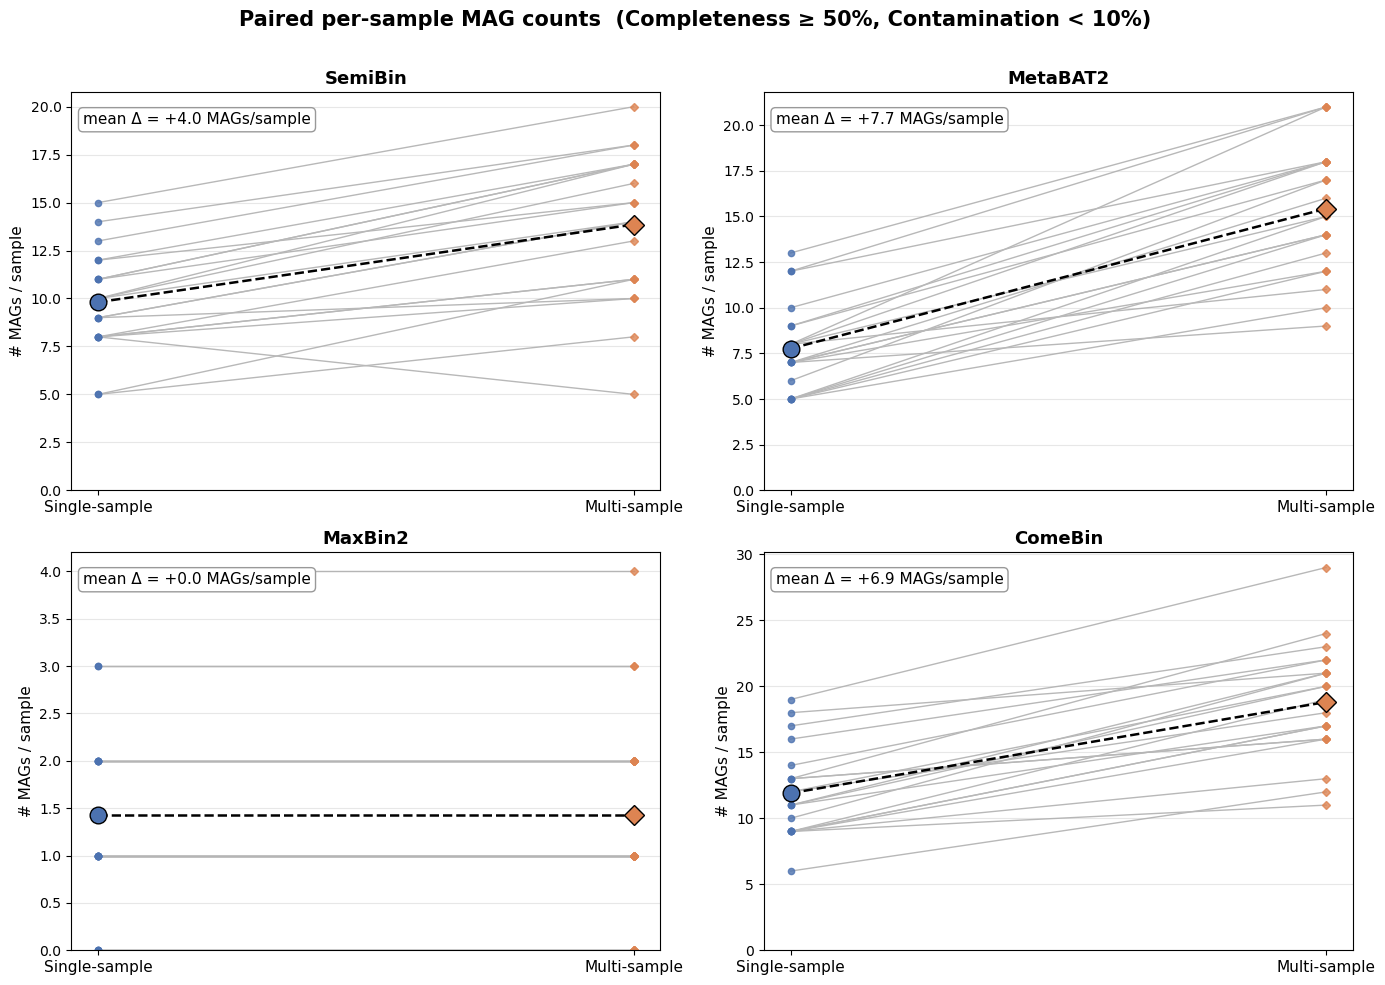

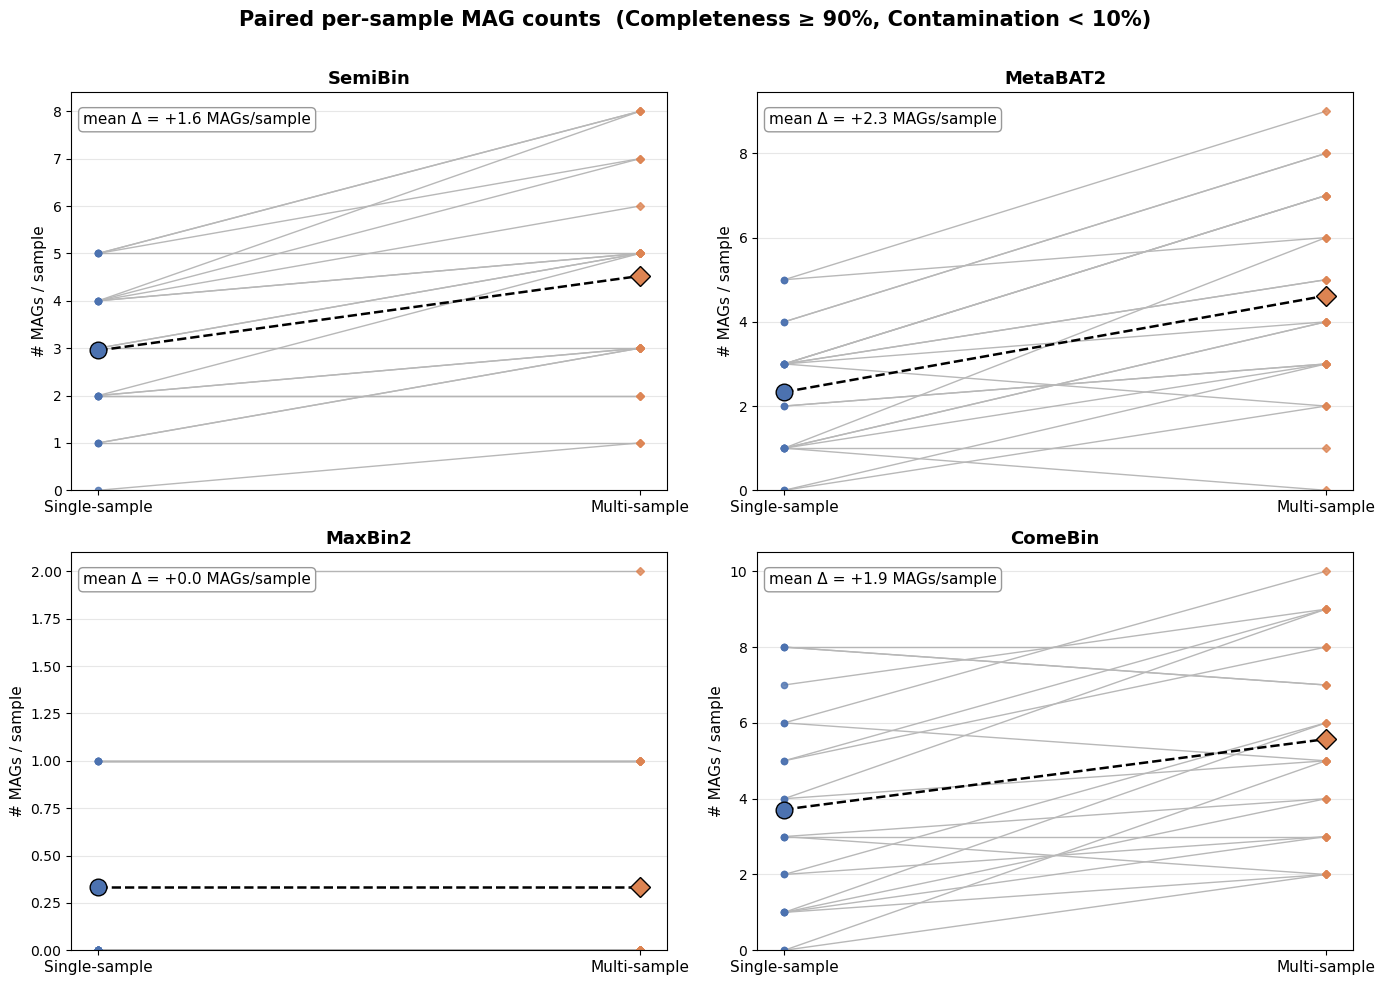

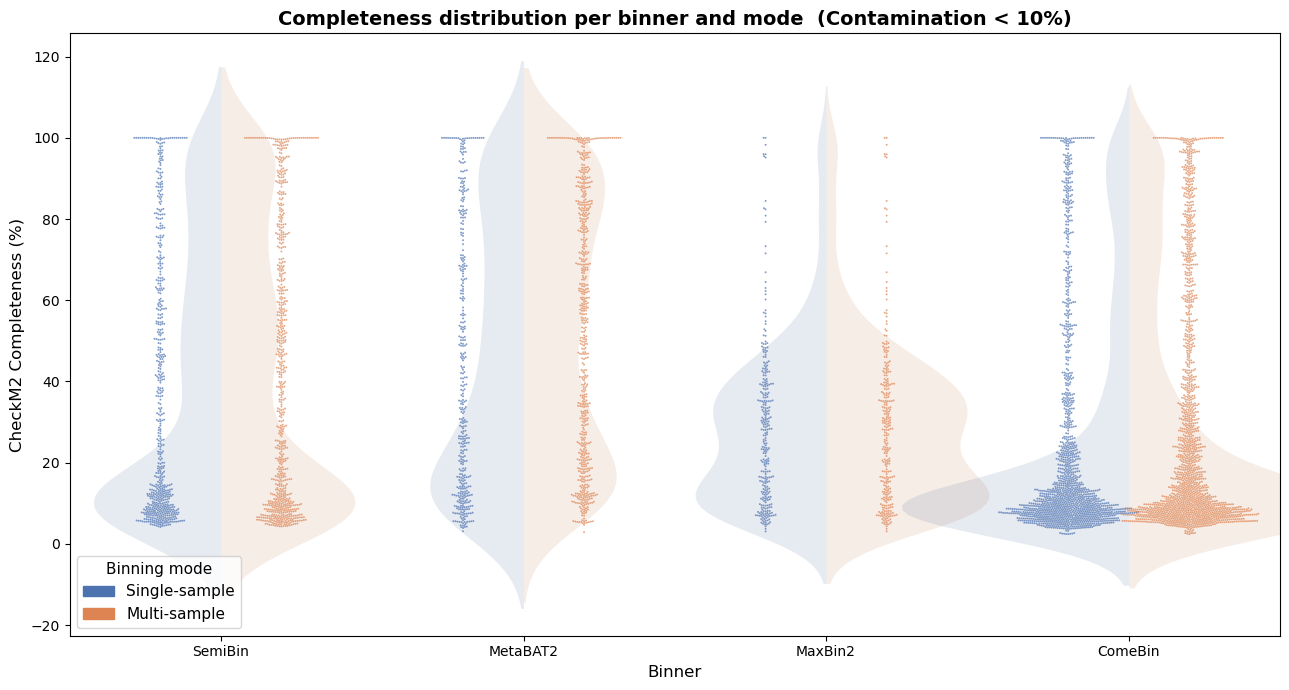

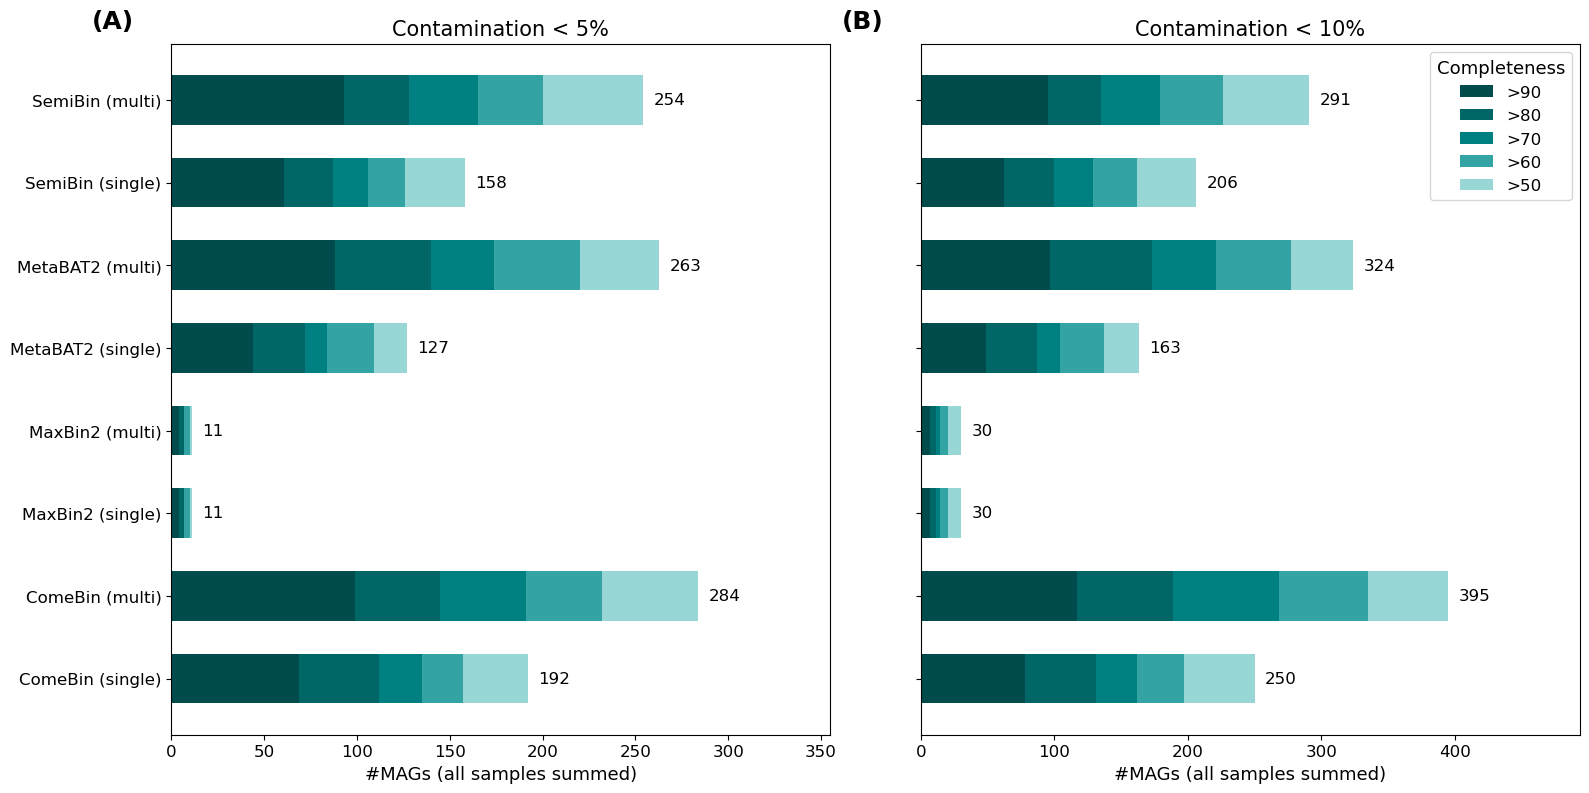

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import re

BINNERS = ["semibin", "metabat2", "maxbin2", "comebin"]
BINNER_LABELS = {
    "semibin": "SemiBin",
    "metabat2": "MetaBAT2",
    "maxbin2": "MaxBin2",
    "comebin": "ComeBin",
}
MODE_LABELS = {"single": "Single-sample", "multi": "Multi-sample"}
MODE_COLORS = {"single": "#4c72b0", "multi": "#dd8452"}

def parse_tag(tag):
    parts = tag.split("-")
    return parts[0], parts[1]  # (binner, mode)

CONTAM_MAX = 10
COMP_MINS = [50, 90]

def mag_count_by_sample(df, binner, mode, comp_min, contam_max):
    tag = f"{binner}-{mode}-sample-binning"
    sub = df[(df["tag"] == tag)
             & (df["Completeness"] >= comp_min)
             & (df["Contamination"] < contam_max)]
    return sub.groupby("source_dataset").size()

samples = sorted(final_df["source_dataset"].unique().tolist(),
                 key=lambda s: int(re.findall(r"\d+", s)[0]))

# ---- Panel A: paired per-sample #MAGs, single vs multi, one subplot per binner ----
def plot_paired(comp_min, contam_max):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, binner in zip(axes.ravel(), BINNERS):
        single = mag_count_by_sample(final_df, binner, "single", comp_min, contam_max)
        multi = mag_count_by_sample(final_df, binner, "multi", comp_min, contam_max)
        s = single.reindex(samples).fillna(0)
        m = multi.reindex(samples).fillna(0)
        x0, x1 = 0.0, 1.0

        for i in range(len(samples)):
            ax.plot([x0, x1], [s.iloc[i], m.iloc[i]], color="0.72", lw=1, zorder=1)
            ax.plot(x0, s.iloc[i], "o", color=MODE_COLORS["single"], ms=4.5, zorder=2, alpha=0.8)
            ax.plot(x1, m.iloc[i], "D", color=MODE_COLORS["multi"], ms=3.8, zorder=2, alpha=0.8)

        ax.plot([x0, x1], [s.mean(), m.mean()], color="k", lw=1.8, ls="--", zorder=3)
        ax.plot(x0, s.mean(), "o", color=MODE_COLORS["single"], ms=12, mec="k", zorder=4)
        ax.plot(x1, m.mean(), "D", color=MODE_COLORS["multi"], ms=10, mec="k", zorder=4)

        delta = m.mean() - s.mean()
        ax.text(0.02, 0.95, f"mean Δ = {delta:+.1f} MAGs/sample",
                transform=ax.transAxes, fontsize=11, va="top",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.6"))

        ax.set_xticks([x0, x1])
        ax.set_xticklabels([MODE_LABELS["single"], MODE_LABELS["multi"]], fontsize=11)
        ax.set_ylabel("# MAGs / sample", fontsize=11)
        ax.set_ylim(bottom=0)
        ax.set_title(BINNER_LABELS[binner], fontsize=13, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)

    fig.suptitle(f"Paired per-sample MAG counts  (Completeness \u2265 {comp_min}%, Contamination < {contam_max}%)",
                 fontsize=15, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

for comp_min in COMP_MINS:
    plot_paired(comp_min, CONTAM_MAX)

# ---- Panel B: completeness swarmplot, split single vs multi per binner ----
plot_df = final_df[final_df["Contamination"] < CONTAM_MAX].copy()
plot_df["binner"] = [BINNER_LABELS[parse_tag(t)[0]] for t in plot_df["tag"]]
plot_df["mode"] = [MODE_LABELS[parse_tag(t)[1]] for t in plot_df["tag"]]
binner_order = [BINNER_LABELS[b] for b in BINNERS]

fig, ax = plt.subplots(figsize=(13, 7))
sns.violinplot(data=plot_df, x="binner", y="Completeness", hue="mode", order=binner_order,
               palette={MODE_LABELS["single"]: MODE_COLORS["single"], MODE_LABELS["multi"]: MODE_COLORS["multi"]}, split=True, inner=None, width=1.5, alpha=0.15, linewidth=0, ax=ax)
sns.swarmplot(data=plot_df, x="binner", y="Completeness", hue="mode", order=binner_order,
              palette={MODE_LABELS["single"]: MODE_COLORS["single"], MODE_LABELS["multi"]: MODE_COLORS["multi"]}, size=1.4, alpha=0.7, dodge=True, ax=ax, legend=False)
ax.set_xlabel("Binner", fontsize=12)
ax.set_ylabel("CheckM2 Completeness (%)", fontsize=12)
ax.set_title(f"Completeness distribution per binner and mode  (Contamination < {CONTAM_MAX}%)",
             fontsize=14, fontweight="bold")
handles = [mpatches.Patch(color=MODE_COLORS[m], label=MODE_LABELS[m]) for m in ["single", "multi"]]
ax.legend(handles=handles, fontsize=11, loc="lower left", title="Binning mode", title_fontsize=11)
plt.tight_layout()
plt.show()

# ---- Panel C: stacked completeness-threshold bars (totals across all samples, like analyse_v2) ----
thresholds = [">90", ">80", ">70", ">60", ">50"]
colors = ["#004c4c", "#006666", "#008080", "#33a3a3", "#99d6d6"]

def assign_threshold(comp):
    if comp >= 90:
        return ">90"
    elif comp >= 80:
        return ">80"
    elif comp >= 70:
        return ">70"
    elif comp >= 60:
        return ">60"
    elif comp >= 50:
        return ">50"
    return None

def summed_counts(df, cont_cutoff):
    result = {thr: [] for thr in thresholds}
    labels = []
    grouped = df.groupby("tag")
    for method, g in grouped:
        df2 = g[g["Contamination"] < cont_cutoff].copy()
        df2["Thr"] = df2["Completeness"].apply(assign_threshold)
        counts = df2["Thr"].value_counts()
        for thr in thresholds:
            result[thr].append(int(counts.get(thr, 0)))
        binner, mode = parse_tag(method)
        labels.append(f"{BINNER_LABELS[binner]} ({mode})")
    def sort_key(lbl):
        tool, mode_raw = lbl.split(" (")
        mode = mode_raw.rstrip(")")
        tool_key = {v: i for i, v in BINNER_LABELS.items()}[tool]
        mode_key = 0 if mode == "single" else 1
        return (tool_key, mode_key)
    order = sorted(range(len(labels)), key=lambda i: sort_key(labels[i]))
    sorted_labels = [labels[i] for i in order]
    sorted_result = {thr: [result[thr][i] for i in order] for thr in thresholds}
    return sorted_labels, sorted_result

def plot_stacked_summary(ax, tools, data, title):
    y = np.arange(len(tools))
    left = np.zeros(len(tools))
    for i, thr in enumerate(thresholds):
        ax.barh(y, data[thr], left=left, color=colors[i], label=thr, height=0.6)
        left += np.array(data[thr])
    for i in range(len(tools)):
        ax.text(left[i] + (max(left) * 0.02 if max(left) > 0 else 0.1), i,
                str(int(left[i])), va="center", ha="left", fontsize=12)
    ax.set_xlim(0, max(left) * 1.25 if max(left) > 0 else 1)
    ax.set_yticks(y)
    ax.set_yticklabels(tools, fontsize=12)
    ax.set_xlabel("#MAGs (all samples summed)", fontsize=13)
    ax.set_title(title, fontsize=15)
    ax.tick_params(axis="x", labelsize=12)

labels5, data5 = summed_counts(final_df, cont_cutoff=5)
labels10, data10 = summed_counts(final_df, cont_cutoff=10)
assert labels5 == labels10

fig, axs = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
plot_stacked_summary(axs[0], labels5, data5, "Contamination < 5%")
plot_stacked_summary(axs[1], labels10, data10, "Contamination < 10%")
axs[0].text(-0.12, 1.05, "(A)", transform=axs[0].transAxes, fontsize=18, fontweight="bold", va="top")
axs[1].text(-0.12, 1.05, "(B)", transform=axs[1].transAxes, fontsize=18, fontweight="bold", va="top")
axs[1].legend(title="Completeness", loc="upper right", fontsize=12, title_fontsize=13)
plt.tight_layout()
plt.show()
